# Category Intelligence — Retail Product Performance EDA

**Calibo AI Academy | Phase 1 — Mini Use Case 01 | Path 2 — KLU**

This notebook answers the business question: **Based on six months of transaction data, which categories are growing or declining, which products are driving or dragging each category, whether discounts are associated with higher revenue per transaction, when sales peak, and what the Category Manager should prioritise or challenge?**

The notebook includes an explicit **Extract → Transform → Load → Analyze (ETL)** cleaning stage before the required EDA.

## CBIM Problem Canvas

| Canvas element | Answer |
|---|---|
| **Situation (S)** | A regional 12-store retail chain is preparing for a quarterly supplier review across Electronics, Apparel, Grocery, Home & Kitchen, and Personal Care. The Category Manager needs evidence for shelf-space and promotional decisions. |
| **Complication (C)** | The manager needs to distinguish growing, stable, and declining categories and identify product-level drivers and weak spots before suppliers present their cases. |
| **Question (Q)** | Which categories are growing or declining, which products are driving or dragging each category, whether discounts are associated with higher revenue per transaction, and when promotions should be timed? |
| **SSOT** | The supplied MUC01 retail sales transaction dataset. |
| **Success definition** | A useful analysis gives a defensible category priority, a specific supplier/product challenge supported by revenue, a discount finding backed by numbers, a promotional-timing signal, and a clear limitation. |
| **Primary stakeholder** | The Category Manager, who needs to leave the supplier review with a concise, data-backed view of where to invest and where to challenge. |

## 0. Extract → Transform → Load → Analyze: Data Cleaning

- **Extract:** Read the supplied CSV.
- **Transform:** Standardize text, parse dates, coerce numeric fields, validate business rules, and create month/day/discount-bracket features.
- **Load:** Use the validated dataframe `df` as the analysis table and export a cleaned CSV.
- **Analyze:** Perform the required category, product, discount, and calendar EDA.

Revenue is reconciled to the documented after-discount formula with a ₹0.01 tolerance for rounding.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

candidates = ["MUC01_Retail_Sales_Dataset.csv", "MUC01_Retail_Sales_Dataset 1.csv"]
DATA_FILE = next((f for f in candidates if Path(f).exists()), None)
if DATA_FILE is None:
    raise FileNotFoundError("Place MUC01_Retail_Sales_Dataset.csv in the same folder as this notebook.")

raw_df = pd.read_csv(DATA_FILE)
df = raw_df.copy()
df.columns = df.columns.str.strip()

for col in ["transaction_id","store_id","store_city","category","product_name"]:
    df[col] = df[col].astype("string").str.strip()

df["date"] = pd.to_datetime(df["date"], errors="coerce")
for col in ["units_sold","unit_price","revenue","discount_pct"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

duplicate_txn = int(df["transaction_id"].duplicated().sum())
missing_rows = int(df.isna().any(axis=1).sum())

invalid_rows = int((
    df["transaction_id"].isna() | df["date"].isna() |
    df["store_id"].isna() | df["store_city"].isna() |
    df["category"].isna() | df["product_name"].isna() |
    df["units_sold"].isna() | df["unit_price"].isna() |
    df["revenue"].isna() | df["discount_pct"].isna() |
    (df["units_sold"] <= 0) | (df["unit_price"] <= 0) |
    (df["revenue"] < 0) | (df["discount_pct"] < 0) |
    (df["discount_pct"] > 30)
).sum())

df["expected_revenue"] = df["units_sold"] * df["unit_price"] * (1 - df["discount_pct"]/100)
df["revenue_difference"] = df["revenue"] - df["expected_revenue"]
revenue_mismatch_rows = int(df["revenue_difference"].abs().gt(0.01).sum())

df["month"] = df["date"].dt.to_period("M").astype(str)
df["day_of_week"] = df["date"].dt.day_name()

def discount_bracket(x):
    return {0:"0%",5:"5%",10:"10%",15:"15%",20:"20%"}.get(x, "25%+")

df["discount_bracket"] = df["discount_pct"].map(discount_bracket)

bad = (
    df["transaction_id"].isna() | df["date"].isna() |
    df["store_id"].isna() | df["store_city"].isna() |
    df["category"].isna() | df["product_name"].isna() |
    df["units_sold"].isna() | df["unit_price"].isna() |
    df["revenue"].isna() | df["discount_pct"].isna() |
    (df["units_sold"] <= 0) | (df["unit_price"] <= 0) |
    (df["revenue"] < 0) | (df["discount_pct"] < 0) |
    (df["discount_pct"] > 30)
)
before_rows = len(df)
df = df.loc[~bad].drop_duplicates("transaction_id", keep="first").copy()
after_rows = len(df)

df.drop(columns=["expected_revenue","revenue_difference"]).to_csv(
    "MUC01_Retail_Sales_Cleaned.csv", index=False
)

print(f"Source file: {DATA_FILE}")
print(f"Rows before cleaning: {before_rows:,}")
print(f"Rows after cleaning:  {after_rows:,}")
print(f"Duplicate transaction IDs: {duplicate_txn:,}")
print(f"Rows with at least one null before cleaning: {missing_rows:,}")
print(f"Critical validation issues: {invalid_rows:,}")
print(f"Revenue mismatches above ₹0.01: {revenue_mismatch_rows:,}")

Source file: MUC01_Retail_Sales_Dataset.csv
Rows before cleaning: 107,836
Rows after cleaning:  107,836
Duplicate transaction IDs: 0
Rows with at least one null before cleaning: 0
Critical validation issues: 0
Revenue mismatches above ₹0.01: 0


### Cleaning result

The supplied data passes the key quality checks: no missing values, duplicate transaction IDs, invalid ranges, or material revenue-definition mismatches were found. The cleaning stage therefore functions mainly as **validation plus analytical transformation**, rather than removing large portions of the dataset.

## 1. Load and Inspect the Data

In [3]:
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nNull values:")
display(df.isna().sum().to_frame("null_count"))

print("\nDescriptive summary:")
display(df.describe().T)

print("\nUnique products:", df["product_name"].nunique())
print("Unique categories:", df["category"].nunique())
print("Unique stores:", df["store_id"].nunique())
print("Unique cities:", df["store_city"].nunique())
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())

Shape: (107836, 15)

Data types:


,dtype
transaction_id,string
date,datetime64[us]
store_id,string
store_city,string
category,string
product_name,string
units_sold,int64
unit_price,float64
revenue,float64
discount_pct,int64



Null values:


,null_count
transaction_id,0
date,0
store_id,0
store_city,0
category,0
product_name,0
units_sold,0
unit_price,0
revenue,0
discount_pct,0



Descriptive summary:


,count,mean,min,25%,50%,75%,max,std
date,107836,2026-04-01 18:11:48.275529,2026-01-01 00:00:00,2026-02-15 00:00:00,2026-04-02 00:00:00,2026-05-17 00:00:00,2026-06-30 00:00:00,NaN
units_sold,107836.0,2.583488,1.0,1.0,2.0,3.0,13.0,1.471616
unit_price,107836.0,1778.097787,50.02,274.8275,488.45,1039.5225,44990.14,5053.631792
revenue,107836.0,4263.920924,40.04,467.7725,1034.615,2473.335,355090.88,14243.244169
discount_pct,107836.0,7.228152,0.0,0.0,5.0,10.0,20.0,6.730445
expected_revenue,107836.0,4263.920946,40.04,467.772,1034.613,2473.330625,355090.88,14243.244154
revenue_difference,107836.0,-0.000022,-0.005,-0.001,0.0,0.001,0.005,0.002352



Unique products: 25
Unique categories: 5
Unique stores: 12
Unique cities: 6
Date range: 2026-01-01 to 2026-06-30


**Business observations:**  
1. The dataset contains a substantial six-month transaction base, supporting category comparisons rather than decisions based on a small sample.  
2. The five-category, 25-product structure allows the manager to move from category performance to specific product-level supplier conversations.  
3. Electronics contributes a disproportionately large share of revenue relative to its transaction count, so its trend has an outsized effect on the chain.

## 2. Category Revenue Trend Over Time

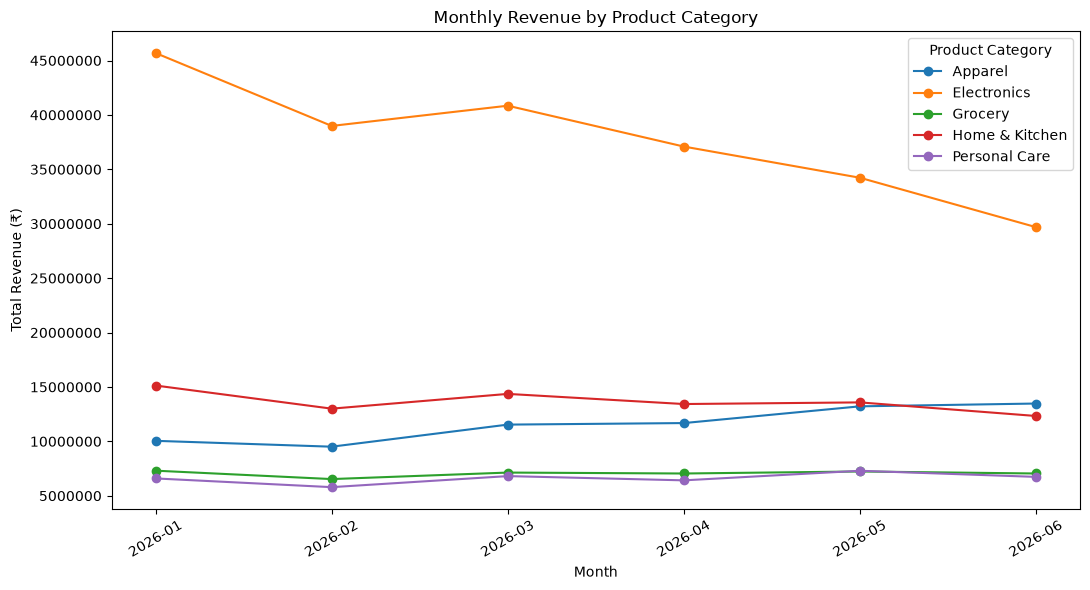

,January Revenue (₹),June Revenue (₹),Change (₹),Change (%),Monthly CV (%)
category,,,,,
Electronics,45686596.63,29686824.81,-15999771.82,-35.02,14.60
Home & Kitchen,15130871.54,12333283.07,-2797588.47,-18.49,7.26
Grocery,7307011.34,7047719.23,-259292.11,-3.55,3.87
Personal Care,6593734.81,6737354.12,143619.31,2.18,7.52
Apparel,10049916.78,13476952.88,3427036.10,34.10,13.88


In [4]:
cat_month = df.groupby(["month", "category"])["revenue"].sum().unstack(fill_value=0)

plt.figure(figsize=(11, 6))
for category in cat_month.columns:
    plt.plot(cat_month.index, cat_month[category], marker="o", label=category)

plt.title("Monthly Revenue by Product Category")
plt.xlabel("Month")
plt.ylabel("Total Revenue (₹)")
plt.legend(title="Product Category")
plt.xticks(rotation=30)
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

cat_summary = pd.DataFrame({
    "January Revenue (₹)": cat_month.loc["2026-01"],
    "June Revenue (₹)": cat_month.loc["2026-06"]
})
cat_summary["Change (₹)"] = cat_summary["June Revenue (₹)"] - cat_summary["January Revenue (₹)"]
cat_summary["Change (%)"] = cat_summary["Change (₹)"] / cat_summary["January Revenue (₹)"] * 100
cat_summary["Monthly CV (%)"] = cat_month.std() / cat_month.mean() * 100
display(cat_summary.sort_values("Change (%)").round(2))

**Business signal:** **Electronics** has the steepest January-to-June decline, falling about **35.0%**. Because Electronics is the largest revenue category, the decline is material to the supplier review. **Grocery** is the most consistent category by monthly coefficient of variation (**3.87%**). **Apparel** has the strongest positive change at **34.1%**, supporting an investment test.

## 3. Top and Bottom Products by Category

In [4]:
product_revenue = df.groupby(["category", "product_name"], as_index=False)["revenue"].sum()

top2 = (
    product_revenue.sort_values(["category", "revenue"], ascending=[True, False])
    .groupby("category").head(2)
)
bottom2 = (
    product_revenue.sort_values(["category", "revenue"], ascending=[True, True])
    .groupby("category").head(2)
)

rows = []
for category in sorted(df["category"].unique()):
    tops = top2[top2["category"] == category].reset_index(drop=True)
    bottoms = bottom2[bottom2["category"] == category].reset_index(drop=True)
    rows.append({
        "Category": category,
        "Top 1 Product": tops.loc[0, "product_name"],
        "Top 1 Revenue (₹)": tops.loc[0, "revenue"],
        "Top 2 Product": tops.loc[1, "product_name"],
        "Top 2 Revenue (₹)": tops.loc[1, "revenue"],
        "Bottom 1 Product": bottoms.loc[0, "product_name"],
        "Bottom 1 Revenue (₹)": bottoms.loc[0, "revenue"],
        "Bottom 2 Product": bottoms.loc[1, "product_name"],
        "Bottom 2 Revenue (₹)": bottoms.loc[1, "revenue"],
    })

product_summary = pd.DataFrame(rows)
display(product_summary.style.format({
    "Top 1 Revenue (₹)": "₹{:,.2f}",
    "Top 2 Revenue (₹)": "₹{:,.2f}",
    "Bottom 1 Revenue (₹)": "₹{:,.2f}",
    "Bottom 2 Revenue (₹)": "₹{:,.2f}",
}))

,Category,Top 1 Product,Top 1 Revenue (₹),Top 2 Product,Top 2 Revenue (₹),Bottom 1 Product,Bottom 1 Revenue (₹),Bottom 2 Product,Bottom 2 Revenue (₹)
0,Apparel,Saree,"₹14,161,864.63",T-Shirt,"₹14,099,251.65",Kurta,"₹13,606,747.03",Formal Shirt,"₹13,748,976.91"
1,Electronics,Headphones,"₹47,696,053.99",Laptop,"₹46,551,078.39",Smart TV,"₹41,882,166.21",Tablet,"₹44,744,388.93"
2,Grocery,Rice (5kg),"₹8,562,171.86",Dal (1kg),"₹8,488,303.64",Sugar (1kg),"₹8,377,786.05",Oil (1L),"₹8,431,630.01"
3,Home & Kitchen,Mixer Grinder,"₹16,903,254.58",Storage Box,"₹16,676,535.31",Water Bottle,"₹15,825,842.17",Pressure Cooker,"₹16,142,329.39"
4,Personal Care,Shampoo,"₹8,168,328.26",Body Lotion,"₹8,106,578.00",Sunscreen,"₹7,593,863.45",Toothpaste,"₹7,768,812.48"


**Supplier-review implication:** **Electronics** is the category to challenge. **Smart TV** is the lowest-revenue Electronics product at **₹41,882,166.21** over six months, alongside the category's steep decline. Apparel's top products — **Saree (₹14,161,864.63)** and **T-Shirt (₹14,099,251.65)** — provide concrete support for its positive trend.

## 4. Discount Effectiveness Analysis

,Transactions,Avg_Revenue_per_Transaction,Avg_Units_Sold
discount_bracket,,,
0%,36033.0,4685.65,2.59
5%,23922.0,4303.73,2.59
10%,23810.0,4005.55,2.57
15%,11935.0,4069.16,2.60
20%,12136.0,3631.73,2.58
25%+,NaN,NaN,NaN


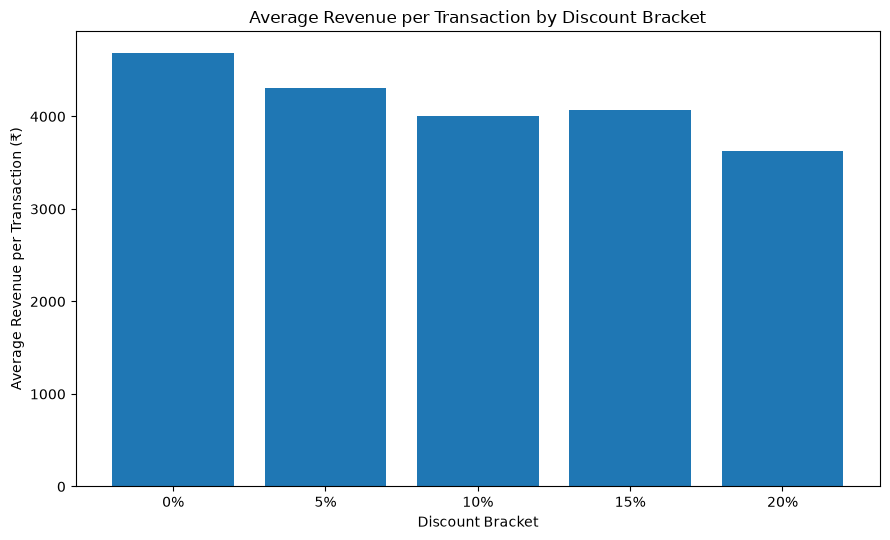

In [5]:
def discount_bracket(x):
    return {0:"0%",5:"5%",10:"10%",15:"15%",20:"20%"}.get(x, "25%+")

df["discount_bracket"] = df["discount_pct"].map(discount_bracket)

discount_summary = (
    df.groupby("discount_bracket", sort=False)
    .agg(
        Transactions=("transaction_id", "count"),
        Avg_Revenue_per_Transaction=("revenue", "mean"),
        Avg_Units_Sold=("units_sold", "mean")
    )
    .reindex(["0%", "5%", "10%", "15%", "20%", "25%+"])
)

display(discount_summary.round(2))

plot_disc = discount_summary.loc[["0%", "5%", "10%", "15%", "20%"]]
plt.figure(figsize=(9, 5.5))
plt.bar(plot_disc.index, plot_disc["Avg_Revenue_per_Transaction"])
plt.title("Average Revenue per Transaction by Discount Bracket")
plt.xlabel("Discount Bracket")
plt.ylabel("Average Revenue per Transaction (₹)")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

**Position backed by the numbers:** Higher discounts do **not** show a meaningful revenue-per-transaction lift in this dataset. Average revenue per transaction falls from **₹4,685.65 at 0%** to **₹3,631.73 at 20%**, a change of **-22.5%**. Average units sold are nearly flat (**2.59 vs 2.58**). This supports scrutiny of deeper discounts. Actual margin erosion cannot be measured because the dataset has no cost or gross-margin field, and discount brackets are observational rather than randomized. The 25%+ bracket has no observations.

## 5. Day-of-Week and Monthly Sales Patterns

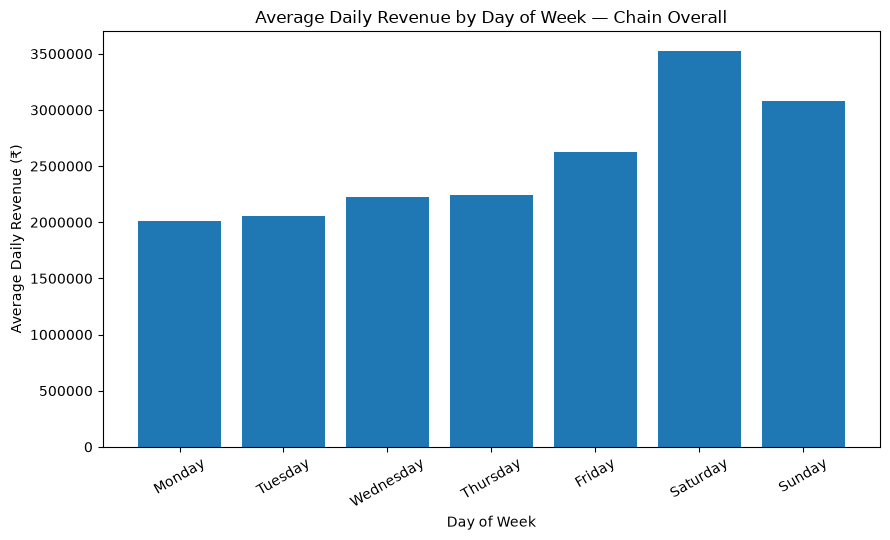

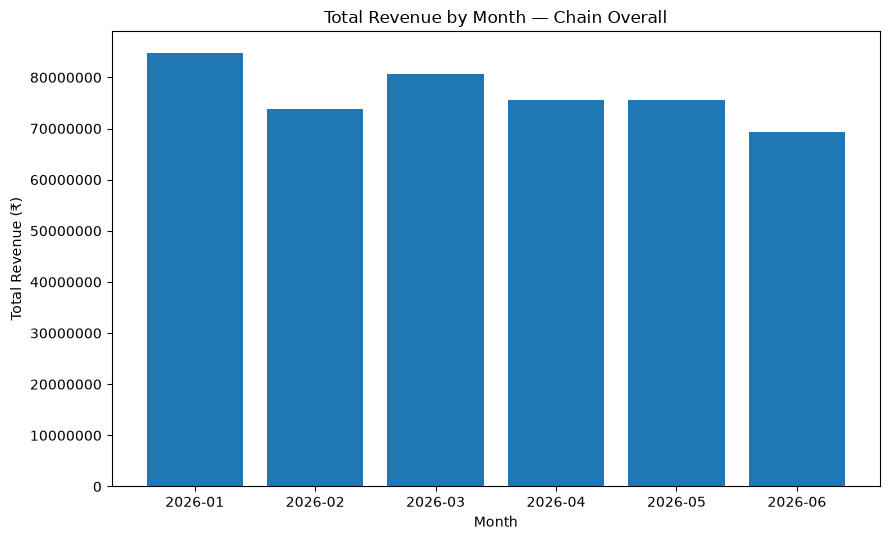

Best chain day: Saturday ₹3,523,605.44 average daily revenue
Worst chain day: Monday ₹2,012,140.96 average daily revenue
Best chain month: 2026-01 ₹84,768,131.10
Worst chain month: 2026-06 ₹69,282,134.11


In [6]:
daily_chain = (
    df.groupby("date", as_index=False)["revenue"]
    .sum()
    .rename(columns={"revenue": "daily_revenue"})
)
daily_chain["day_of_week"] = daily_chain["date"].dt.day_name()

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
chain_dow = daily_chain.groupby("day_of_week")["daily_revenue"].mean().reindex(dow_order)

plt.figure(figsize=(9, 5.5))
plt.bar(chain_dow.index, chain_dow.values)
plt.title("Average Daily Revenue by Day of Week — Chain Overall")
plt.xlabel("Day of Week")
plt.ylabel("Average Daily Revenue (₹)")
plt.xticks(rotation=30)
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

monthly = df.groupby("month")["revenue"].sum().to_frame("total_revenue")
monthly["MoM Change (%)"] = monthly["total_revenue"].pct_change() * 100

plt.figure(figsize=(9, 5.5))
plt.bar(monthly.index, monthly["total_revenue"])
plt.title("Total Revenue by Month — Chain Overall")
plt.xlabel("Month")
plt.ylabel("Total Revenue (₹)")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

print("Best chain day:", chain_dow.idxmax(), f"₹{chain_dow.max():,.2f} average daily revenue")
print("Worst chain day:", chain_dow.idxmin(), f"₹{chain_dow.min():,.2f} average daily revenue")
print("Best chain month:", monthly["total_revenue"].idxmax(), f"₹{monthly['total_revenue'].max():,.2f}")
print("Worst chain month:", monthly["total_revenue"].idxmin(), f"₹{monthly['total_revenue'].min():,.2f}")

**Timing signal:** **Saturday** is the strongest weekday by average daily revenue, while **Tuesday** is the weakest. **January** is the strongest month by total revenue and **June** is the weakest. Electronics follows the same broad weekday and monthly pattern. This supports concentrating promotional activity around strong weekend demand while using weaker days for targeted tests rather than broad discounting.

### Electronics: category-specific timing

,Average Daily Revenue (₹)
day_of_week,
Monday,970975.52
Tuesday,975432.75
Wednesday,1111579.33
Thursday,1061517.79
Friday,1291063.65
Saturday,1786658.45
Sunday,1558130.36


,Total Revenue (₹)
month,
2026-01,45686596.63
2026-02,38988602.50
2026-03,40846509.47
2026-04,37092265.09
2026-05,34226926.43
2026-06,29686824.81


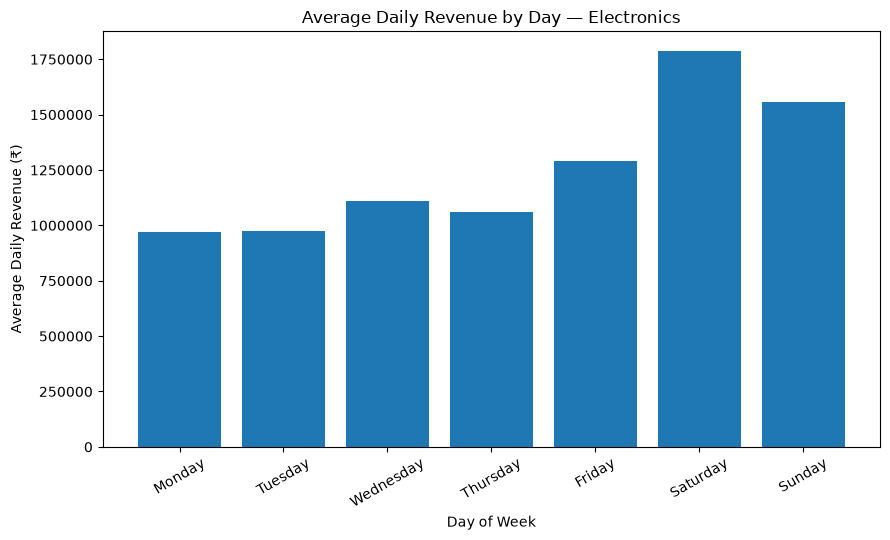

In [7]:
interesting_category = "Electronics"

daily_interesting = (
    df[df["category"] == interesting_category]
    .groupby("date", as_index=False)["revenue"]
    .sum()
    .rename(columns={"revenue": "daily_revenue"})
)
daily_interesting["day_of_week"] = daily_interesting["date"].dt.day_name()

interesting_dow = (
    daily_interesting.groupby("day_of_week")["daily_revenue"]
    .mean()
    .reindex(dow_order)
)
interesting_month = df[df["category"] == interesting_category].groupby("month")["revenue"].sum()

display(interesting_dow.to_frame("Average Daily Revenue (₹)").round(2))
display(interesting_month.to_frame("Total Revenue (₹)").round(2))

plt.figure(figsize=(9, 5.5))
plt.bar(interesting_dow.index, interesting_dow.values)
plt.title("Average Daily Revenue by Day — Electronics")
plt.xlabel("Day of Week")
plt.ylabel("Average Daily Revenue (₹)")
plt.xticks(rotation=30)
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

## 6. Category Manager Briefing

**Apparel has the strongest growth case:** revenue increased **34.1%** from January to June, with Saree and T-Shirt among its strongest products. **Electronics should be challenged:** it declined **35.0%**, and Smart TV generated **₹41,882,166.21** over six months. **Discounts should be scrutinised:** average revenue per transaction is **22.5% lower** at 20% discount than at 0%, while average units sold are almost flat. **Promotions should favour Saturdays**, which have the highest average daily revenue for both the chain and Electronics. Before a final investment decision, request product cost/gross-margin and inventory/promotion-exposure data so profitability and true incremental uplift can be assessed.